In [5]:
import pandas as pd

df = pd.read_csv("C:/Users/Asus/Downloads/funnel_events_sample.csv")

In [6]:
print(df)

    user_id                step            timestamp
0      U177        visited_site  2026-07-20 04:03:00
1      U073      email_verified  2026-07-20 04:28:00
2      U056      signup_started  2026-07-20 03:51:00
3      U077        visited_site  2026-07-20 04:01:00
4      U003      signup_started  2026-07-20 04:18:00
..      ...                 ...                  ...
537    U055      email_verified  2026-07-20 04:32:00
538    U007        visited_site  2026-07-20 03:57:00
539    U008        visited_site  2026-07-20 03:53:00
540    U172      details_filled  2026-07-20 04:24:00
541    U139  purchase_completed  2026-07-20 04:57:00

[542 rows x 3 columns]


In [7]:
stage_users = (
    df.groupby("step")["user_id"]
      .nunique()
)

In [9]:
print(stage_users)

step
details_filled         96
email_verified         52
purchase_completed     44
signup_started        150
visited_site          200
Name: user_id, dtype: int64


In [10]:
order = [
    "Visited Site",
    "Signup Started",
    "Details Filled",
    "Email Verified",
    "Purchase Completed"
]

stage_users = stage_users.reindex(order)

In [11]:
print(order)

['Visited Site', 'Signup Started', 'Details Filled', 'Email Verified', 'Purchase Completed']


In [12]:
print(stage_users)

step
Visited Site         NaN
Signup Started       NaN
Details Filled       NaN
Email Verified       NaN
Purchase Completed   NaN
Name: user_id, dtype: float64


In [13]:
result = pd.DataFrame({
    "Users": stage_users
})

result["Conversion %"] = (
    result["Users"] /
    result["Users"].shift(1) * 100
)

result.iloc[0, 1] = 100

In [14]:
print(result)

                    Users  Conversion %
step                                   
Visited Site          NaN         100.0
Signup Started        NaN           NaN
Details Filled        NaN           NaN
Email Verified        NaN           NaN
Purchase Completed    NaN           NaN


In [15]:
result["Drop-off"] = (
    result["Users"].shift(1) -
    result["Users"]
)

result.iloc[0, 2] = 0

In [16]:
print(result["Drop-off"])

step
Visited Site          0.0
Signup Started        NaN
Details Filled        NaN
Email Verified        NaN
Purchase Completed    NaN
Name: Drop-off, dtype: float64


In [17]:
leak = result["Drop-off"].idxmax()

print("Biggest Leak:", leak)

Biggest Leak: Visited Site


In [18]:
print(result)

                    Users  Conversion %  Drop-off
step                                             
Visited Site          NaN         100.0       0.0
Signup Started        NaN           NaN       NaN
Details Filled        NaN           NaN       NaN
Email Verified        NaN           NaN       NaN
Purchase Completed    NaN           NaN       NaN


In [19]:
print(df["step"].unique())

['visited_site' 'email_verified' 'signup_started' 'purchase_completed'
 'details_filled']


In [20]:
print(stage_users)

step
Visited Site         NaN
Signup Started       NaN
Details Filled       NaN
Email Verified       NaN
Purchase Completed   NaN
Name: user_id, dtype: float64


In [21]:
print(df["step"].unique())

['visited_site' 'email_verified' 'signup_started' 'purchase_completed'
 'details_filled']


In [23]:
df["step"] = df["step"].str.strip()

In [24]:
print(df["step"].unique())

['visited_site' 'email_verified' 'signup_started' 'purchase_completed'
 'details_filled']


In [25]:
print(df.head())

  user_id            step            timestamp
0    U177    visited_site  2026-07-20 04:03:00
1    U073  email_verified  2026-07-20 04:28:00
2    U056  signup_started  2026-07-20 03:51:00
3    U077    visited_site  2026-07-20 04:01:00
4    U003  signup_started  2026-07-20 04:18:00


In [26]:
print(df["step"].unique())

['visited_site' 'email_verified' 'signup_started' 'purchase_completed'
 'details_filled']


In [27]:
import pandas as pd

df = pd.read_csv("C:/Users/Asus/Downloads/funnel_events_sample.csv")

# Count unique users at each stage
stage_users = df.groupby("step")["user_id"].nunique()

# Correct order (exactly as in the CSV)
order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

stage_users = stage_users.reindex(order)

result = pd.DataFrame({"Users": stage_users})

# Conversion %
result["Conversion %"] = (result["Users"] / result["Users"].shift(1)) * 100
result.iloc[0, result.columns.get_loc("Conversion %")] = 100

# Drop-off
result["Drop-off"] = result["Users"].shift(1) - result["Users"]
result.iloc[0, result.columns.get_loc("Drop-off")] = 0

print(result)

# Biggest leak
idx = result["Drop-off"].idxmax()
prev = order[order.index(idx) - 1]

print(f"\nBiggest Leak: {prev} → {idx}")

                    Users  Conversion %  Drop-off
step                                             
visited_site          200    100.000000       0.0
signup_started        150     75.000000      50.0
details_filled         96     64.000000      54.0
email_verified         52     54.166667      44.0
purchase_completed     44     84.615385       8.0

Biggest Leak: signup_started → details_filled


In [28]:
idx = result["Drop-off"].idxmax()
prev = order[order.index(idx) - 1]

print(f"Biggest Leak: {prev} → {idx}")

Biggest Leak: signup_started → details_filled


In [32]:
print("The biggest funnel leak is between signup_started and details_filled, where 54 users dropped off (36% drop). This indicates users are facing friction while filling their details. The product team should investigate form length, validation errors, UX issues, or page performance at this step.")

The biggest funnel leak is between signup_started and details_filled, where 54 users dropped off (36% drop). This indicates users are facing friction while filling their details. The product team should investigate form length, validation errors, UX issues, or page performance at this step.


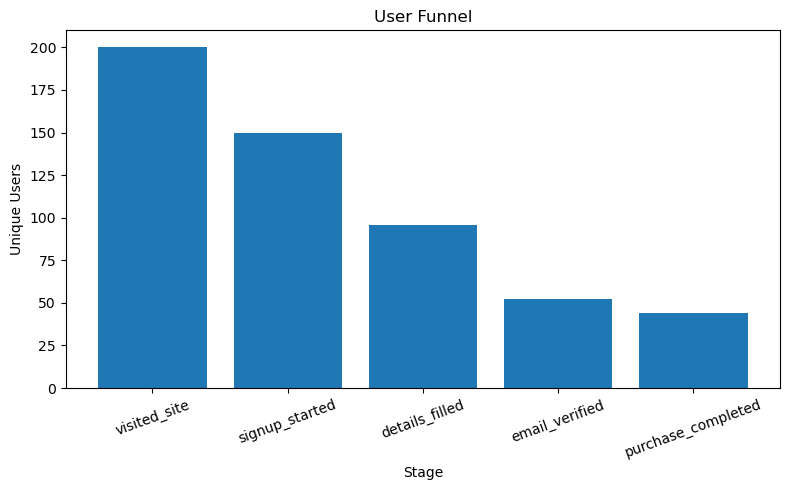

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(result.index, result["Users"])
plt.title("User Funnel")
plt.xlabel("Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

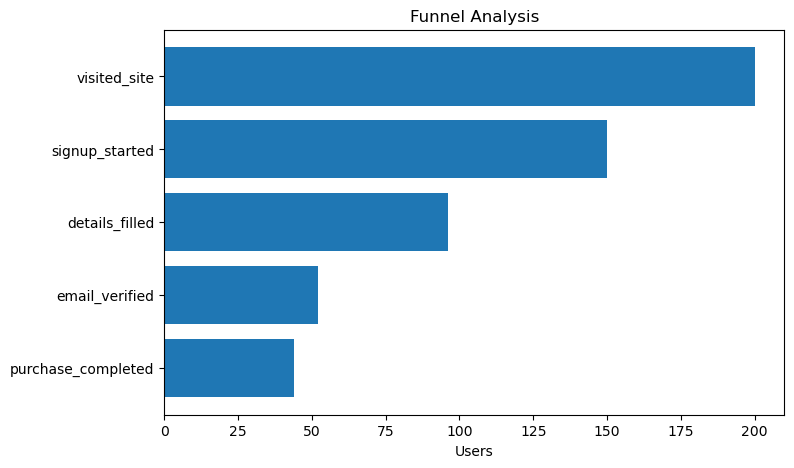

In [34]:
plt.figure(figsize=(8,5))
plt.barh(result.index, result["Users"])
plt.gca().invert_yaxis()
plt.title("Funnel Analysis")
plt.xlabel("Users")
plt.show()

In [35]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

pivot = df.pivot_table(
    index="user_id",
    columns="step",
    values="timestamp",
    aggfunc="min"
)

pivot["visit_to_signup"] = (
    pivot["signup_started"] -
    pivot["visited_site"]
).dt.total_seconds()/60

pivot["signup_to_details"] = (
    pivot["details_filled"] -
    pivot["signup_started"]
).dt.total_seconds()/60

pivot["details_to_verify"] = (
    pivot["email_verified"] -
    pivot["details_filled"]
).dt.total_seconds()/60

pivot["verify_to_purchase"] = (
    pivot["purchase_completed"] -
    pivot["email_verified"]
).dt.total_seconds()/60

print(pivot.mean(numeric_only=True))

step
visit_to_signup       14.680000
signup_to_details     15.521739
details_to_verify           NaN
verify_to_purchase          NaN
dtype: float64


In [36]:
idx = result["Drop-off"].idxmax()

prev = order[order.index(idx)-1]

print(f"⚠ Biggest Funnel Leak: {prev} → {idx}")

⚠ Biggest Funnel Leak: signup_started → details_filled


In [37]:
df["segment"] = df["user_id"].str[-1].astype(int) % 2

df["segment"] = df["segment"].replace({
    0:"Even Users",
    1:"Odd Users"
})

segment = (
    df.groupby(["segment","step"])["user_id"]
      .nunique()
      .unstack()
)

print(segment)

step        details_filled  email_verified  purchase_completed  \
segment                                                          
Even Users              48              26                  22   
Odd Users               48              26                  22   

step        signup_started  visited_site  
segment                                   
Even Users              75           100  
Odd Users               75           100  
